##Classification Task: Classical Classification on CIFAR-10

### Baseline Models

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import CIFAR10
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
## load data CIFAR 10
train_dataset = CIFAR10(root="./data", train=True, download=True)
test_dataset = CIFAR10(root="./data", train=False, download=True)

print("Train images shape:", train_dataset.data.shape)
print("Test images shape:", test_dataset.data.shape)

100%|██████████| 170M/170M [02:48<00:00, 1.01MB/s]


Train images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)


After loading the data we got that we have:
train-50,000 pictures and test-10,000 pictures.The size is: 32*32*3.

First,we need to understand the data and see that everything alright.


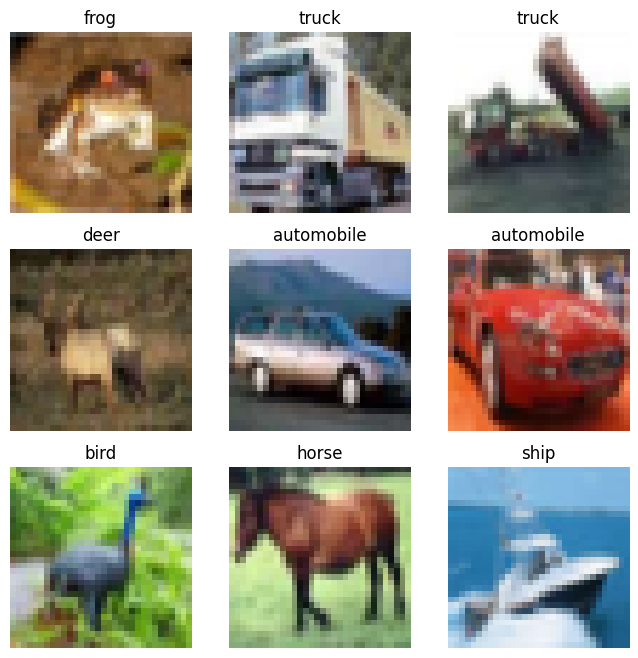

In [3]:
classes = train_dataset.classes ## understand the data

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_dataset.data[i])
    plt.title(classes[train_dataset.targets[i]])
    plt.axis("off")

plt.show()

We can see 9 pictures.The pictures in the CIFAR 10 dataset are small 32*32 , which may cause them to appear blurry when displayed.Despite the low resolution,they contain enough information for classification tasks.


Now we exchange to vectors

In [4]:
X_full = train_dataset.data.reshape(len(train_dataset.data), -1)
y_full = np.array(train_dataset.targets)

X_test = test_dataset.data.reshape(len(test_dataset.data), -1)
y_test = np.array(test_dataset.targets)

print("Flattened train shape:", X_full.shape)
print("Flattened test shape:", X_test.shape)

Flattened train shape: (50000, 3072)
Flattened test shape: (10000, 3072)


We got that every picture turned to 3072 numbers.


In [5]:
## train \validation split
X_train, X_val, y_train, y_val = train_test_split(

    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)## 20%-to validation

Train shape: (40000, 3072)
Validation shape: (10000, 3072)


The original CIFAR 10 training set contains 50,000 Pictures.
We split it into 40,000 training pictures and 10,000 validation pictures
using an 80/20 split in order to tune model hyperparameters.

### Multiclass Logistic Regression (Softmax)

We train a multinomial logistic regression classifier for the CIFAR 10
classification task.The model learns a linear decision boundary in the
feature space and uses the softmax function to produce probabilities
for the ten classes.

We tune the regularization parameter C using validation accuracy.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [7]:
scaler = StandardScaler() ##standrization

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(40000, 3072)
(10000, 3072)
(10000, 3072)


In [8]:
X_train_small = X_train_scaled[:10000]
y_train_small = y_train[:10000]

X_val_small = X_val_scaled[:2000]
y_val_small = y_val[:2000]

log_model = LogisticRegression(
    max_iter=200,
    multi_class="multinomial",
    solver="lbfgs"
)

log_model.fit(X_train_small, y_train_small)

y_val_pred_log = log_model.predict(X_val_small)

log_acc = accuracy_score(y_val_small, y_val_pred_log)

print("Validation Accuracy (Logistic Regression):", log_acc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Validation Accuracy (Logistic Regression): 0.3225


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression Results

The multinomial logistic regression model achieved a validation accuracy of
approximately 32.3\% on the CIFAR-10 subset.

This result serves as a baseline for the classification task.
Since logistic regression is a linear model, its performance is limited on
image data, where class boundaries are often more complex.

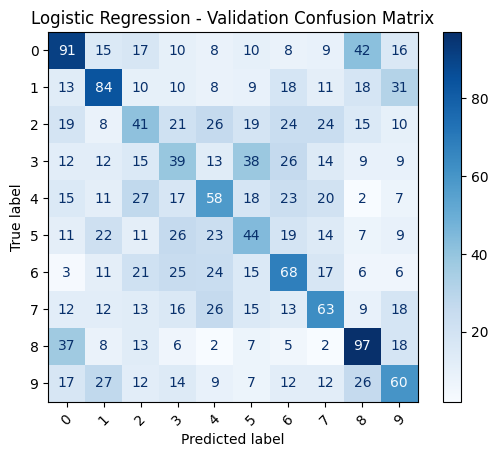

In [9]:
cm_log = confusion_matrix(y_val_small, y_val_pred_log) ##confusion matrix

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.show()

The confusion matrix provides insight into how the logistic regression model
classifies the CIFAR-10 images. Correct predictions appear along the diagonal,
while off diagonal values represent misclassifications.

We observe that several classes are frequently confused with one another.
This behavior is expected because logistic regression is a linear model and
cannot fully capture the complex visual patterns present in natural images.

##Linear Support Vector Machine (SVM)




We train a linear SVM classifier on the same train/validation split used
for the logistic regression model.The goal is to compare the performance
of another linear classifier on the CIFAR-10 classification task.

In [10]:
X_train_small = X_train_scaled[:3000]
y_train_small = y_train[:3000]

X_val_small = X_val_scaled[:1000]
y_val_small = y_val[:1000]

print(X_train_small.shape, X_val_small.shape)

(3000, 3072) (1000, 3072)
